# Euro FX Futures: Roll Timing
**FINM 37000 | Sidharth Saha | Draft for team review**

## Question
When does trading shift from the front contract to the second quarterly contract? This helps us choose a roll window before testing whether rolling becomes more expensive.

## Hypothesis
The shift happens in a similar period each quarter.

## Method
Examine daily volume for the eight rolls from December 2024 to September 2026. Calculate the second contract's share of combined volume. Define crossover as the first observation above 50%, followed by two more available observations above 50%.

To rerun, use a Python environment with `databento`, `pandas`, `matplotlib`, and `ipykernel`. Enter your API key at the prompt and review the cost estimate before downloading.

## Data

In [2]:
import getpass
import databento as db
import pandas as pd
import matplotlib.pyplot as plt

client = db.Historical(key=getpass.getpass("Databento API key: "))


In [4]:
rolls = [
    ("Dec 2024", "6EZ4", "6EH5", "2024-11-01", "2024-12-20"),
    ("Mar 2025", "6EH5", "6EM5", "2025-02-01", "2025-03-22"),
    ("Jun 2025", "6EM5", "6EU5", "2025-05-01", "2025-06-21"),
    ("Sep 2025", "6EU5", "6EZ5", "2025-08-01", "2025-09-20"),
    ("Dec 2025", "6EZ5", "6EH6", "2025-11-01", "2025-12-20"),
    ("Mar 2026", "6EH6", "6EM6", "2026-02-01", "2026-03-21"),
    ("Jun 2026", "6EM6", "6EU6", "2026-05-01", "2026-06-20"),
    ("Sep 2026", "6EU6", "6EZ6", "2026-08-01", "2026-09-19"),
]

requests = {}
total_cost = 0

for label, front, second, start, end in rolls:
    params = {
        "dataset": "GLBX.MDP3",
        "schema": "ohlcv-1d",
        "symbols": [front, second],
        "stype_in": "raw_symbol",
        "start": start,
        "end": end,
    }
    requests[label] = params

    cost = client.metadata.get_cost(**params)
    total_cost += cost
    print(f"{label}: ${cost:.6f}")

print(f"\nTotal estimated cost: ${total_cost:.6f}")


Dec 2024: $0.000803
Mar 2025: $0.000793
Jun 2025: $0.000832
Sep 2025: $0.000813
Dec 2025: $0.000793
Mar 2026: $0.000783
Jun 2026: $0.000813
Sep 2026: $0.000793

Total estimated cost: $0.006421


In [5]:
roll_data = {}

for label, params in requests.items():
    data = client.timeseries.get_range(**params)
    roll_data[label] = data.to_df()
    print(f"{label}: {len(roll_data[label])} rows")

display(roll_data["Sep 2026"].head())
print(roll_data["Sep 2026"].columns.tolist())


Dec 2024: 81 rows
Mar 2025: 80 rows
Jun 2025: 84 rows


C:\Users\15126\AppData\Local\Temp\ipykernel_41272\3287997623.py:4: BentoWarning: The streaming request contained one or more days which have reduced quality: 2025-09-17 (degraded). See: https://databento.com/docs/api-reference-historical/metadata/metadata-get-dataset-condition
  data = client.timeseries.get_range(**params)


Sep 2025: 82 rows


C:\Users\15126\AppData\Local\Temp\ipykernel_41272\3287997623.py:4: BentoWarning: The streaming request contained one or more days which have reduced quality: 2025-11-28 (degraded). See: https://databento.com/docs/api-reference-historical/metadata/metadata-get-dataset-condition
  data = client.timeseries.get_range(**params)


Dec 2025: 80 rows


...

Jun 2026: 82 rows


C:\Users\15126\AppData\Local\Temp\ipykernel_41272\3287997623.py:4: BentoWarning: The streaming request contained one or more days which have reduced quality: 2026-08-29 (degraded). See: https://databento.com/docs/api-reference-historical/metadata/metadata-get-dataset-condition
  data = client.timeseries.get_range(**params)


Sep 2026: 80 rows


,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
ts_event,,,,,,,,,
2026-08-02 00:00:00+00:00,35,1,5510,1.16075,1.16190,1.16070,1.16095,28,6EZ6
2026-08-02 00:00:00+00:00,35,1,10573,1.15620,1.15785,1.15615,1.15625,7188,6EU6
2026-08-03 00:00:00+00:00,35,1,10573,1.15630,1.15755,1.15200,1.15260,131671,6EU6
2026-08-03 00:00:00+00:00,35,1,5510,1.16095,1.16095,1.15630,1.15700,343,6EZ6
2026-08-04 00:00:00+00:00,35,1,5510,1.15720,1.15925,1.15660,1.15910,128,6EZ6


['rtype', 'publisher_id', 'instrument_id', 'open', 'high', 'low', 'close', 'volume', 'symbol']


## Front and Second Contract Volume

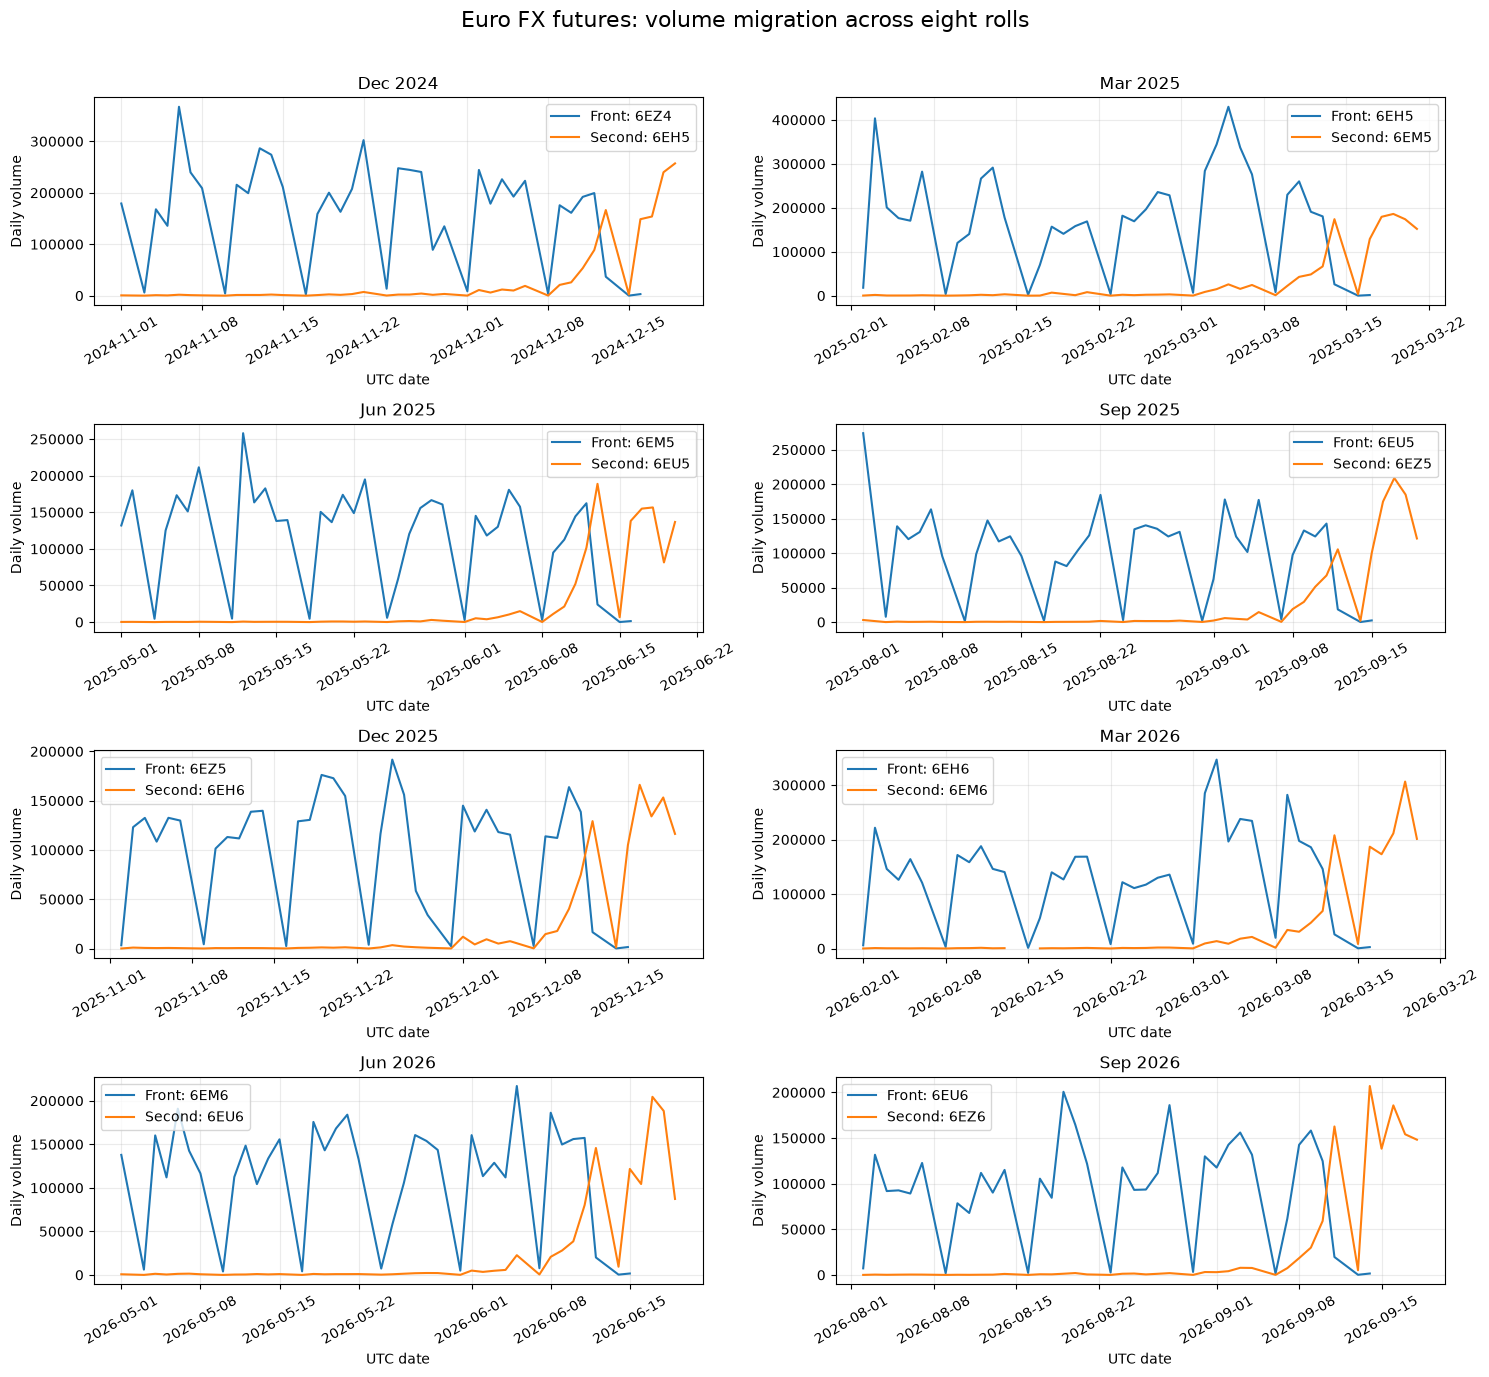

In [7]:
fig, axes = plt.subplots(4, 2, figsize=(15, 14))
volume_tables = {}

for ax, (label, front, second, _, _) in zip(axes.flat, rolls):
    daily = (
        roll_data[label]
        .reset_index()
        .pivot_table(
            index="ts_event",
            columns="symbol",
            values="volume",
            aggfunc="sum",
        )
        .sort_index()
        .reindex(columns=[front, second])
    )

    total = daily[front] + daily[second]
    daily["second_share"] = daily[second] / total.where(total > 0)
    volume_tables[label] = daily

    ax.plot(daily.index, daily[front], label=f"Front: {front}")
    ax.plot(daily.index, daily[second], label=f"Second: {second}")

    ax.set_title(label)
    ax.set_ylabel("Daily volume")
    ax.set_xlabel("UTC date")
    ax.tick_params(axis="x", rotation=30)
    ax.legend()
    ax.grid(alpha=0.25)

fig.suptitle("Euro FX futures: volume migration across eight rolls", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Crossover Dates

In [8]:
summary = []

for label, front, second, _, _ in rolls:
    daily = volume_tables[label]
    valid = daily.dropna(subset=[front, second])
    above = valid["second_share"] > 0.5

    sustained = (
        above
        & above.shift(-1, fill_value=False)
        & above.shift(-2, fill_value=False)
    )

    dates = valid.index[sustained]

    summary.append({
        "roll": label,
        "sustained_crossover_utc": dates[0].date() if len(dates) else None,
        "paired_observations": len(valid),
    })

crossover_summary = pd.DataFrame(summary)
display(crossover_summary)


,roll,sustained_crossover_utc,paired_observations
0,Dec 2024,2024-12-13,39
1,Mar 2025,2025-03-14,38
2,Jun 2025,2025-06-13,40
3,Sep 2025,2025-09-12,39
4,Dec 2025,2025-12-12,38
5,Mar 2026,2026-03-13,37
6,Jun 2026,2026-06-12,39
7,Sep 2026,2026-09-11,38


In [10]:
crossover_summary["weekday"] = pd.to_datetime(
    crossover_summary["sustained_crossover_utc"]
).dt.day_name()

display(crossover_summary)


,roll,sustained_crossover_utc,paired_observations,weekday
0,Dec 2024,2024-12-13,39,Friday
1,Mar 2025,2025-03-14,38,Friday
2,Jun 2025,2025-06-13,40,Friday
3,Sep 2025,2025-09-12,39,Friday
4,Dec 2025,2025-12-12,38,Friday
5,Mar 2026,2026-03-13,37,Friday
6,Jun 2026,2026-06-12,39,Friday
7,Sep 2026,2026-09-11,38,Friday


## Second Contract’s Volume Share

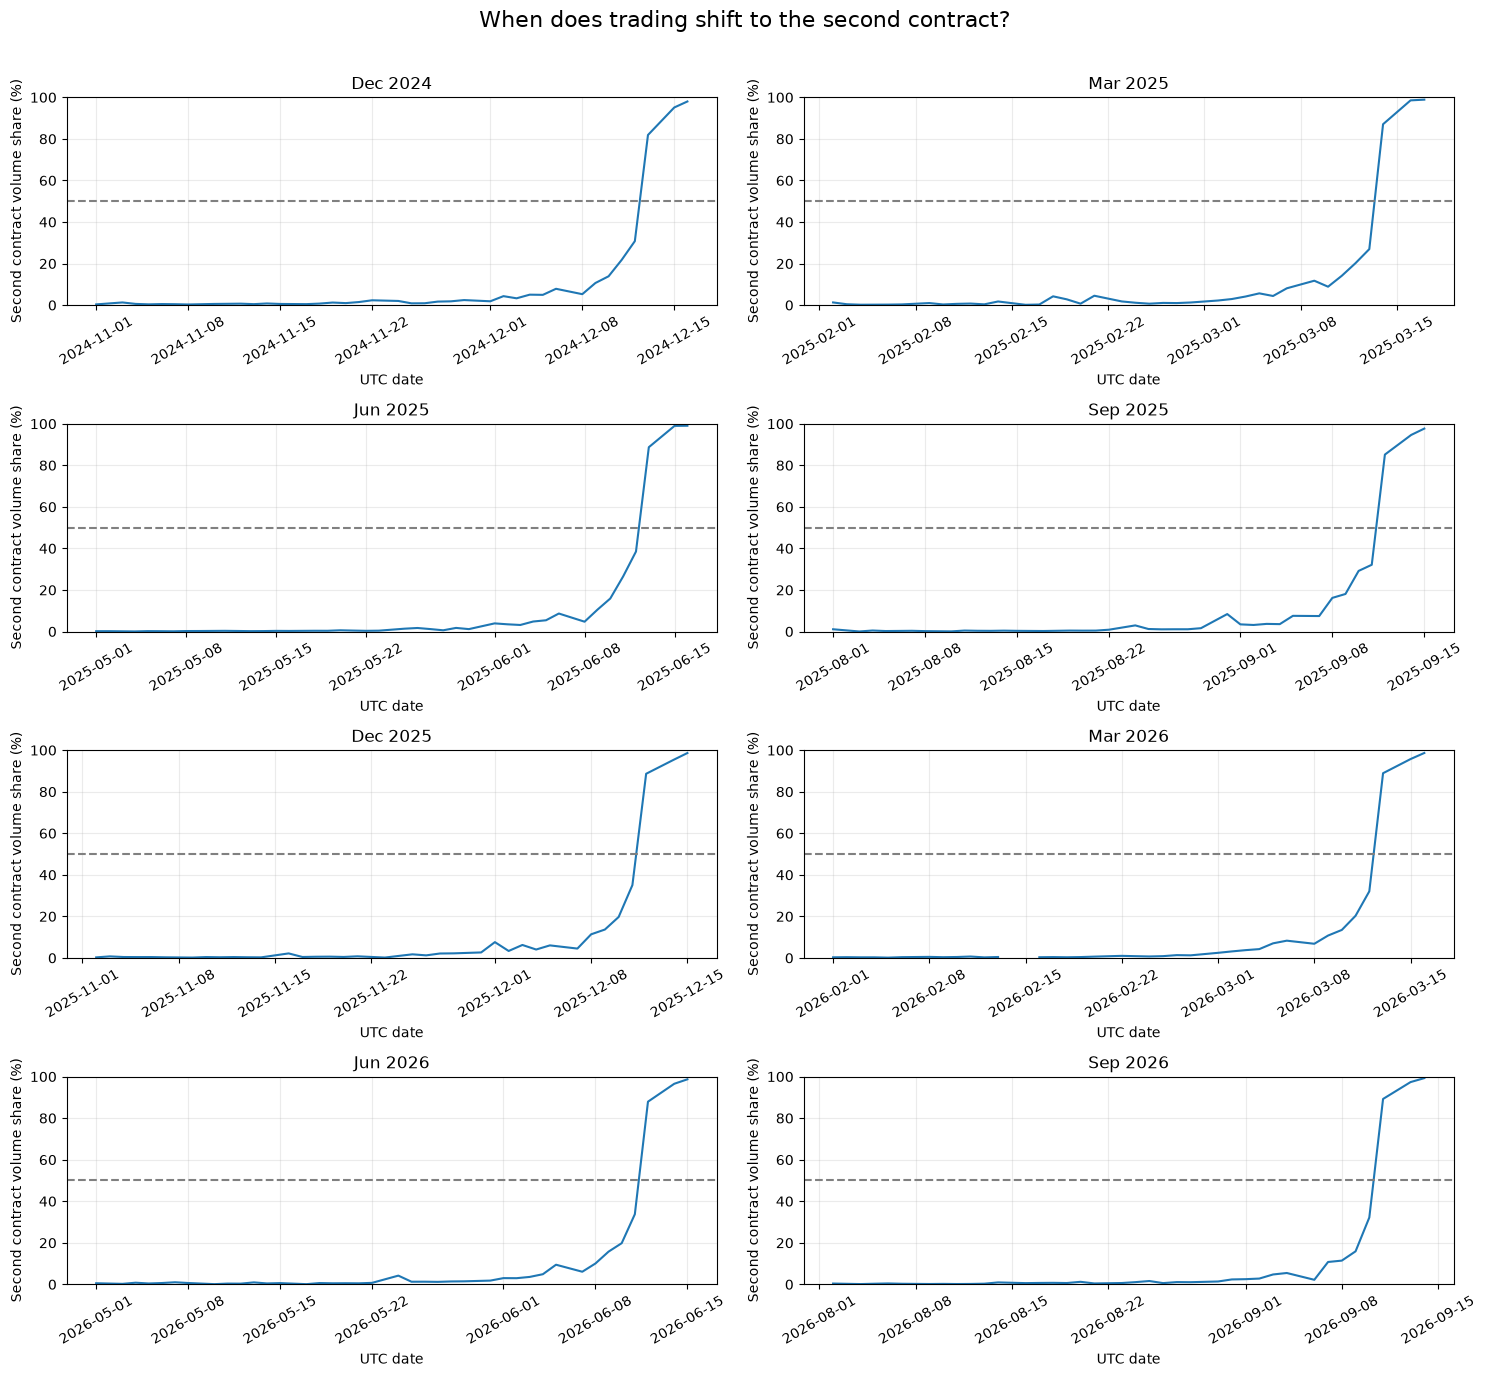

In [11]:
fig, axes = plt.subplots(4, 2, figsize=(15, 14))

for ax, (label, _, _, _, _) in zip(axes.flat, rolls):
    daily = volume_tables[label]

    ax.plot(daily.index, daily["second_share"] * 100)
    ax.axhline(50, color="gray", linestyle="--")

    ax.set_title(label)
    ax.set_ylabel("Second contract volume share (%)")
    ax.set_xlabel("UTC date")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(alpha=0.25)

fig.suptitle("When does trading shift to the second contract?", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Finding and Proposal
All eight crossover dates are Fridays preceding the third Wednesday of the expiry month. Second-contract volume share builds beforehand and reaches roughly 80–90% at crossover.

**Proposal for team review:** use the Monday–Friday week ending on that Friday as a candidate roll window, and check a wider window for robustness.

This shows volume migration, **not increased roll costs**. Crossover is not the start of rolling. Dates are UTC daily-bar labels; session timing and expiry dates need verification. The three observations may include Sunday or skip missing dates.

Databento flagged degraded dates: Sep 17, 2025; Nov 28, 2025; Mar 15–16, 2026; May 24, 2026; and Aug 29, 2026. The March flags affect the observations following crossover and need review.

**Next step:** agree on the window, then compare spread changes with normal weeks using a separate historical sample.